# SUA cliques in cortical space, pooled across RS and NATIM

## Import

In [1]:
import os
os.chdir('/CSNG/studekat/ripple_paper_clean_copy/code_new_filter')

In [2]:
from functions_analysis import *
import pandas as pd
import numpy as np
import yaml
import pickle
import neo
import matplotlib.pyplot as plt
from scipy.stats import binomtest, chi2_contingency
from statsmodels.stats.multitest import multipletests

## Parameters

In [3]:
with open("/CSNG/studekat/ripple_paper_clean_copy/code_new_filter/params_analysis.yml") as f:
    params = yaml.safe_load(f)

DATA_FOLDER = params['data_folder']  # folder with all the preprocessed data
DATES = params['dates']

DF_FOLDER = '/CSNG/studekat/ripple_paper_clean_copy/dataframes_new_filter'  # original version of the dataframes loading
MONKEY_LIST = ['L','N','F']  # NATIM only exists for N and F - handled below by checking each monkey's dates dict
AREAS_MERGED = params['areas_merged']
FINAL_CLASSES = params['final_classes']
COLORS_CLASSES = params['colors_class']

# One folder per condition, matching SF3_cliques_space_RS / SF8_cliques_space_NATIM
CONDITION_FOLDERS = {
    'RS':    'sua_prop_all',
    'NATIM': 'sua_prop_all_NATIM',
}

In [4]:
L_coors =np.array([[1,1],[0,0],[0,1],[2,2],  # row, col, the first 4 arrays
           [1,2],[2,3],[1,3],[2,4],
           [1,7],[2,7],[3,7],[1,6],
           [2,6],[1,5],[2,5],[1,4]])

In [5]:
N_coors =np.array([[1,4],[2,3],[2,4],[1,5],  # row, col, the first 4 arrays
           [2,5],[1,6],[2,7],[1,7],
           [1,2],[1,3],[0,4],[0,3],
           [0,2],[1,1],[0,1],[0,0]])

In [6]:
F_coors = np.array([[1,9],[0,9],[1,8],[0,8],  # row, col, the first 4 arrays
           [1,7],[0,7],[1,6],[1,5],
           [0,0],[0,1],[1,1],[0,2],
           [1,2],[0,3],[0,4],[0,5]])

In [7]:
A_coors = np.array([[1,1],[0,0],[0,1],[2,2],  # row, col, the first 4 arrays
           [1,2],[2,3],[1,3],[2,4],
           [1,7],[2,7],[3,7],[1,6],
           [2,6],[1,5],[2,5],[1,4]])

In [8]:
arrays_coors = {'A':A_coors,
              'L':L_coors,
              'N':N_coors,
              'F':F_coors,}
n_rows_dict = {'A':4,
              'L':4,
              'N':3,
              'F':2,}
n_cols_dict = {'A':8,
              'L':8,
              'N':8,
              'F':10,}

## Functions

Same clique-assignment logic as `SF3_cliques_space_RS` / `SF8_cliques_space_NATIM` (unchanged, so results here are directly comparable to those notebooks). Note `'DOWN_wide'` deliberately counts toward both `count_orange` and `count_blue`.

In [9]:
def aux_units_on_ch(df_sua_all,array,final_classes=FINAL_CLASSES):
    """
    Returns dictionary with unit types on each of the channels.
    """
    df_arr = df_sua_all[df_sua_all['array']==array]
    ch_dict = {k:[] for k in range(64)}
    for ch in range(64):
        df_arr_ch = df_arr[df_arr['channel_order']==ch]
        for cl in final_classes:
            df_cl = df_arr_ch[df_arr_ch['final_class']==cl]
            num_cl_ch = df_cl.shape[0]
            for i in range(num_cl_ch):
                ch_dict[ch].append(cl)
    return ch_dict

In [10]:
def aux_dominant_clique_on_ch(ch_dict):
    """
    Given the distribution of units per channel decides which clique it belongs to.
    """
    clique_dict = {}
    for ch in range(64):
        ch_classes = ch_dict[ch]
        count_orange = sum(v in ['DOWN_wide', 'DOWN_narrow_shallow','DOWN_medium_shallow'] for v in ch_classes)
        count_blue = sum(v in ['UP','DOWN_wide', 'DOWN_narrow_sharp','DOWN_medium_sharp'] for v in ch_classes)
        if count_orange<1 & count_blue<1:
            clique_dict[ch] = 'white'
        elif count_orange>count_blue:
            clique_dict[ch] = 'orange'
        elif count_orange<count_blue:
            clique_dict[ch] = 'blue'
        else:
            clique_dict[ch] = 'gray'
    return clique_dict

## Plotting - pool RS + NATIM, all dates, per monkey

Same spatial-map layout as the pooled-day cells in the two source notebooks, but `monkey_dfs_list` now collects dates from **both** conditions before concatenating, so `clique_dict` for each array reflects units seen in RS and NATIM recordings together. Monkey L has no NATIM dates (`params['dates']['L']` has no `'NATIM'` key) so it is pooled over RS only, same as before.

L RS 20170725
L RS 20170809
L RS 20170810


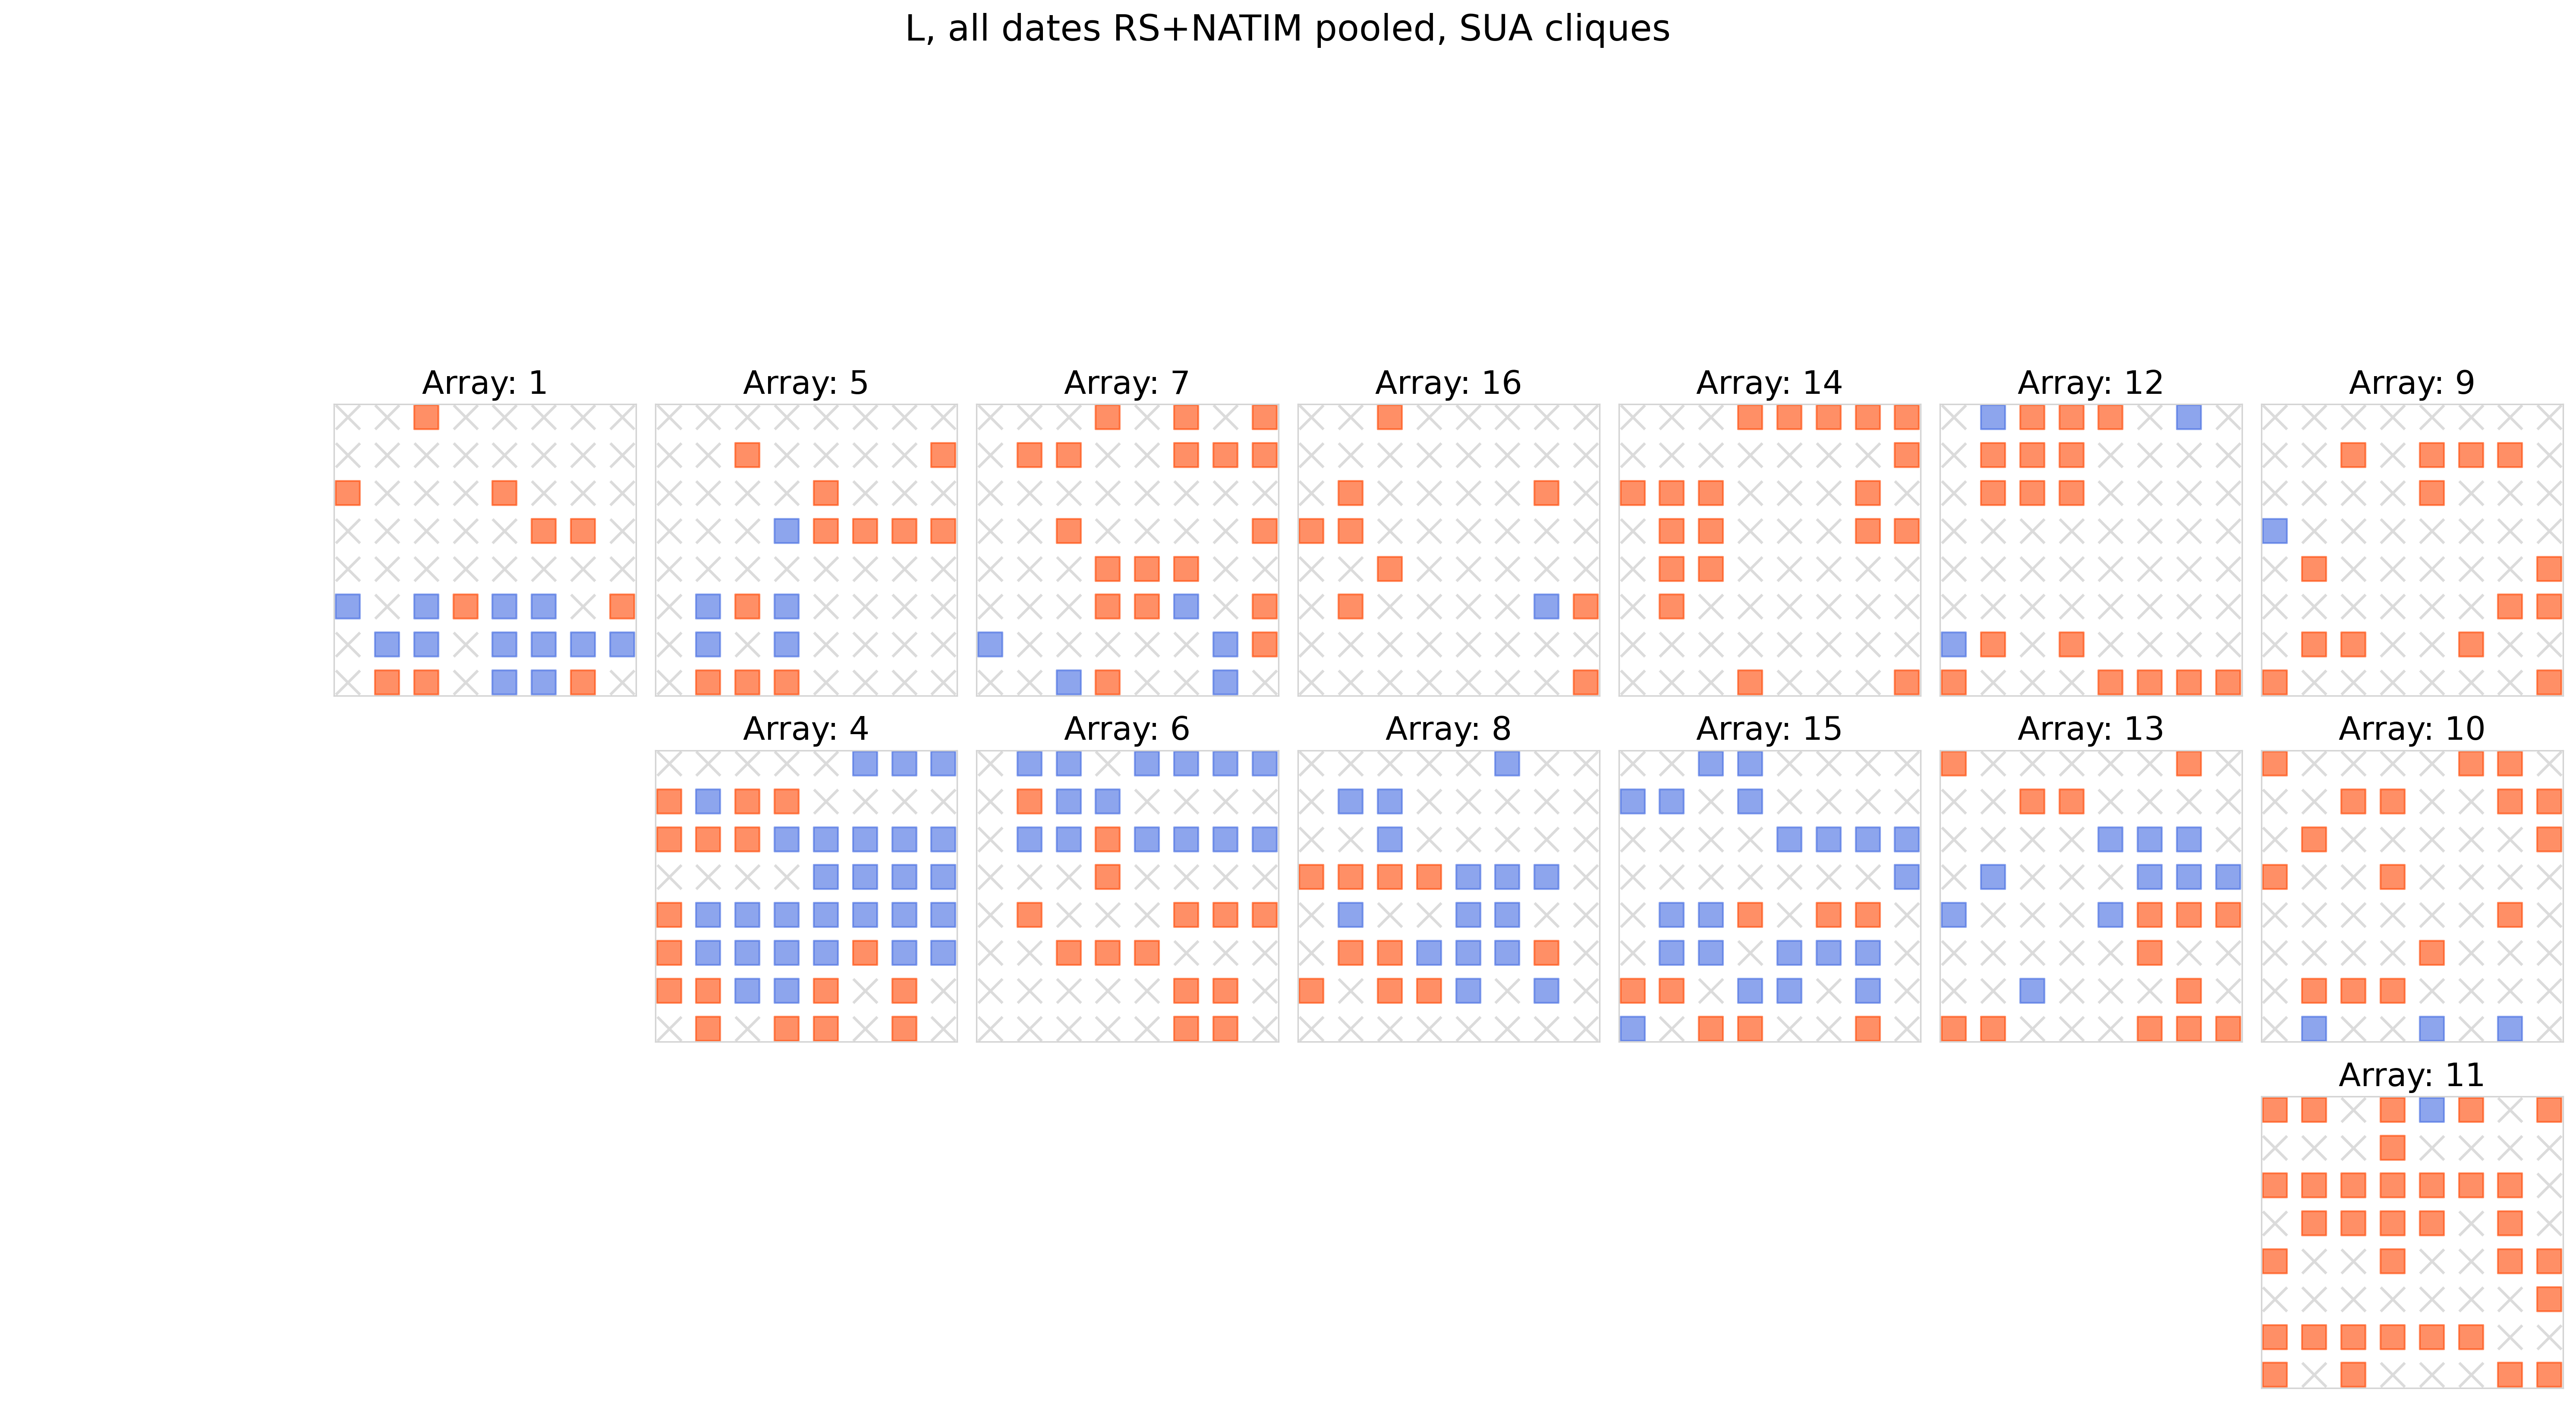

L: {'orange': 209, 'blue': 119, 'gray': 568, 'white': 0} (896 channels classified)

N RS 20240719_B1
N RS 20240719_B2
N NATIM 20220111_B1
N NATIM 20220111_B2
N NATIM 20220111_B3
N NATIM 20220111_B4
N NATIM 20220111_B5
N NATIM 20220111_B6
N NATIM 20220111_B7
N NATIM 20220111_B8
N NATIM 20220111_B9
N NATIM 20220111_B10
N NATIM 20220112_B1
N NATIM 20220112_B2
N NATIM 20220112_B3
N NATIM 20220112_B4
N NATIM 20220112_B5
N NATIM 20220112_B6
N NATIM 20220112_B7
N NATIM 20220112_B8
N NATIM 20220112_B9
N NATIM 20220112_B10
N NATIM 20220112_B11
N NATIM 20220113_B1
N NATIM 20220113_B2
N NATIM 20220113_B3
N NATIM 20220113_B4
N NATIM 20220114_B1
N NATIM 20220114_B2
N NATIM 20220114_B3


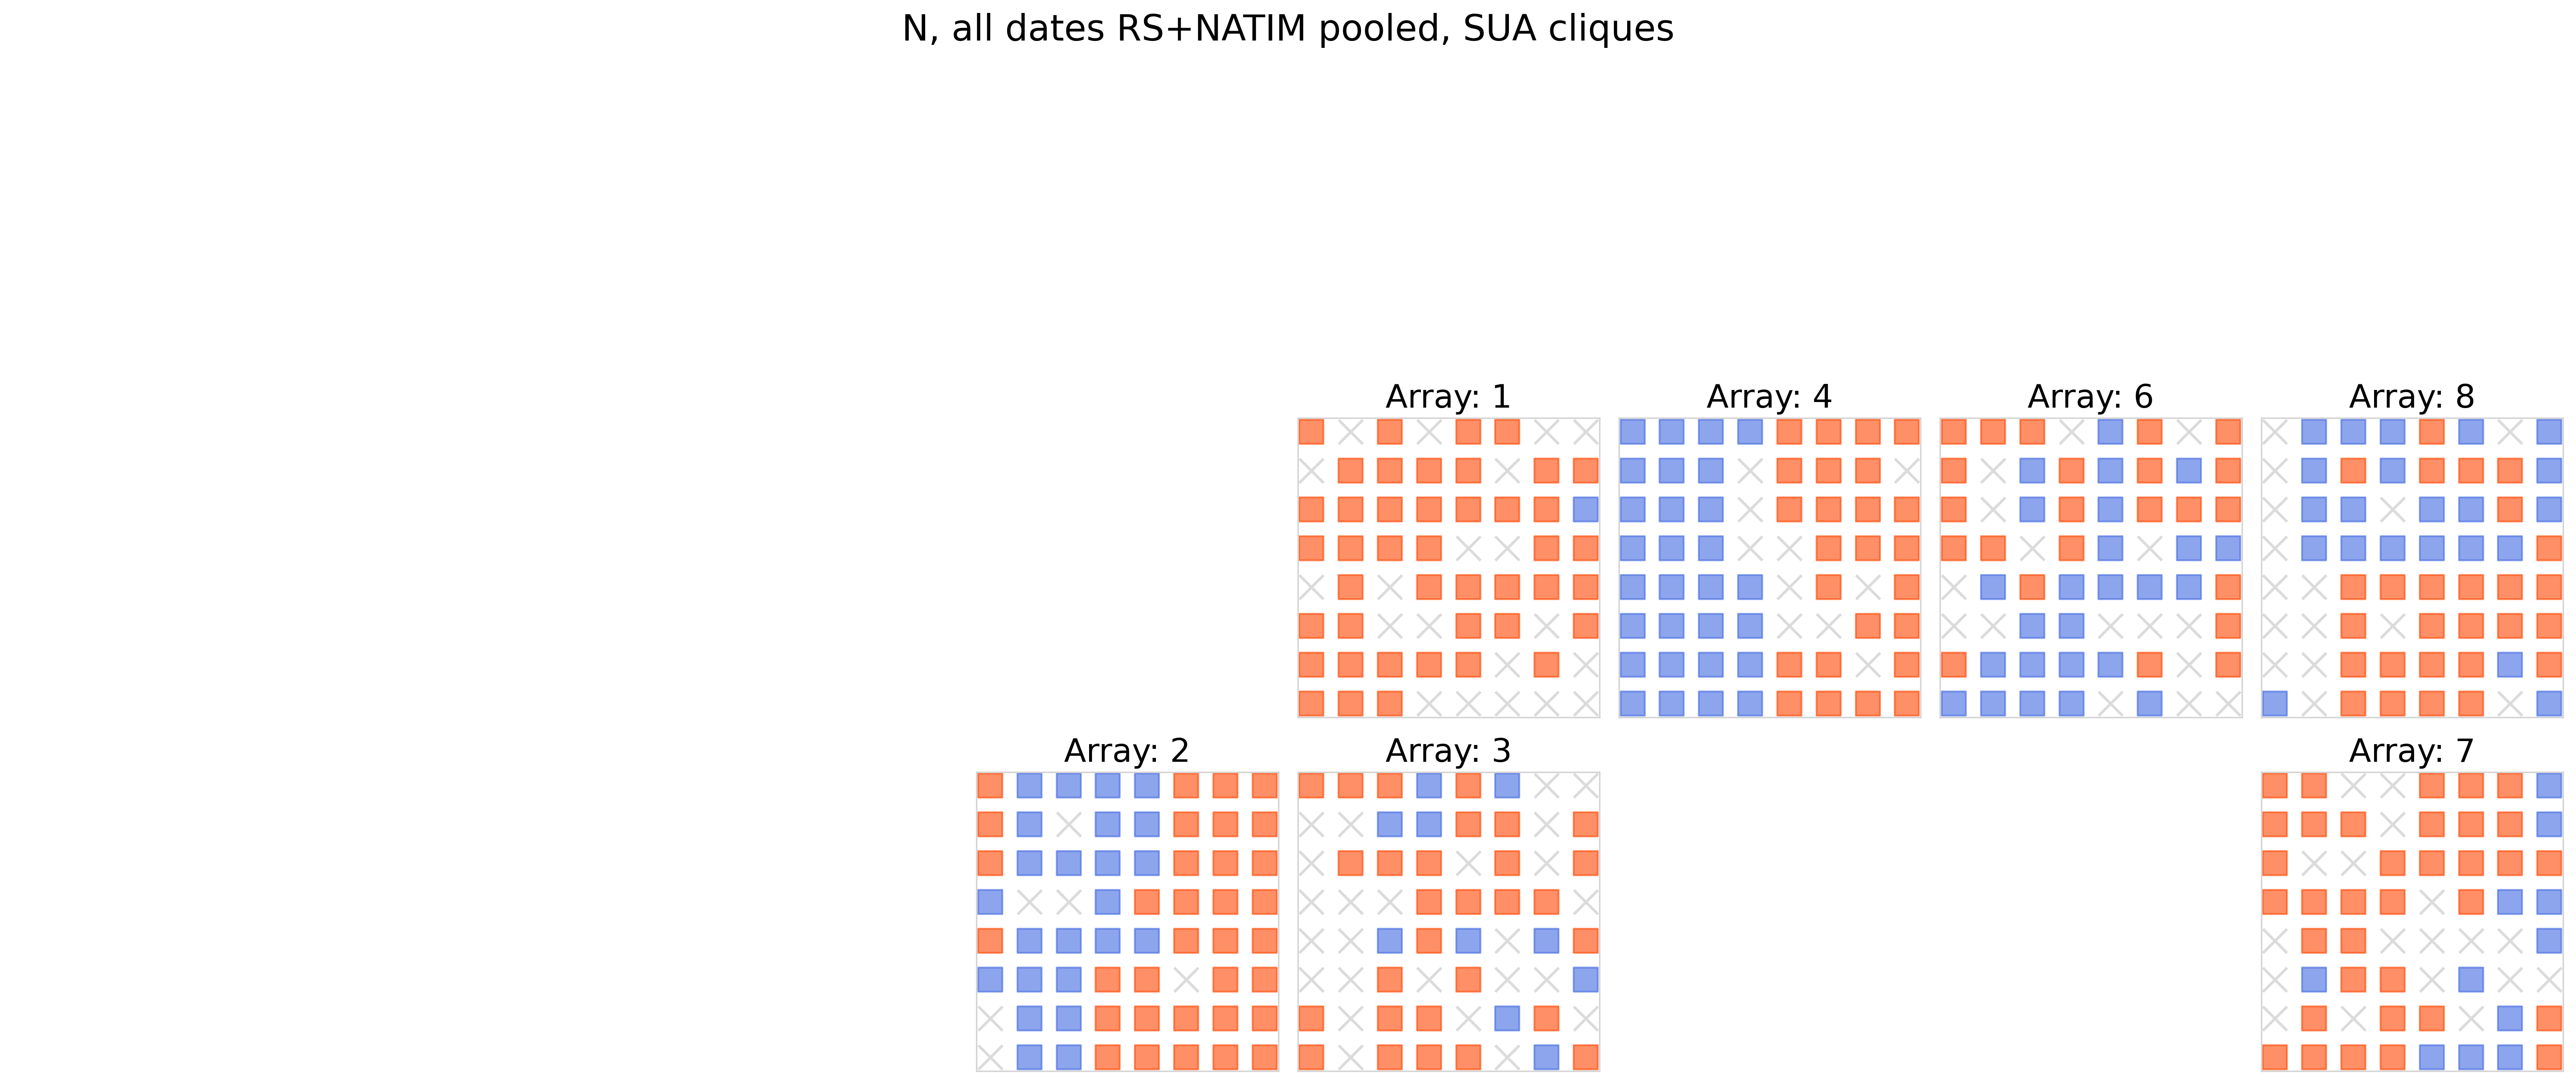

N: {'orange': 216, 'blue': 122, 'gray': 110, 'white': 0} (448 channels classified)

F RS 20240122_B1
F RS 20241216_B1
F NATIM 20240112_B1
F NATIM 20240112_B2
F NATIM 20240112_B3
F NATIM 20240112_B4
F NATIM 20240115_B1
F NATIM 20240115_B2
F NATIM 20240115_B3
F NATIM 20240115_B4
F NATIM 20240115_B5
F NATIM 20240116_B1
F NATIM 20240116_B2
F NATIM 20240116_B3
F NATIM 20240116_B4
F NATIM 20240116_B5
F NATIM 20240118_B1
F NATIM 20240118_B2
F NATIM 20240118_B3


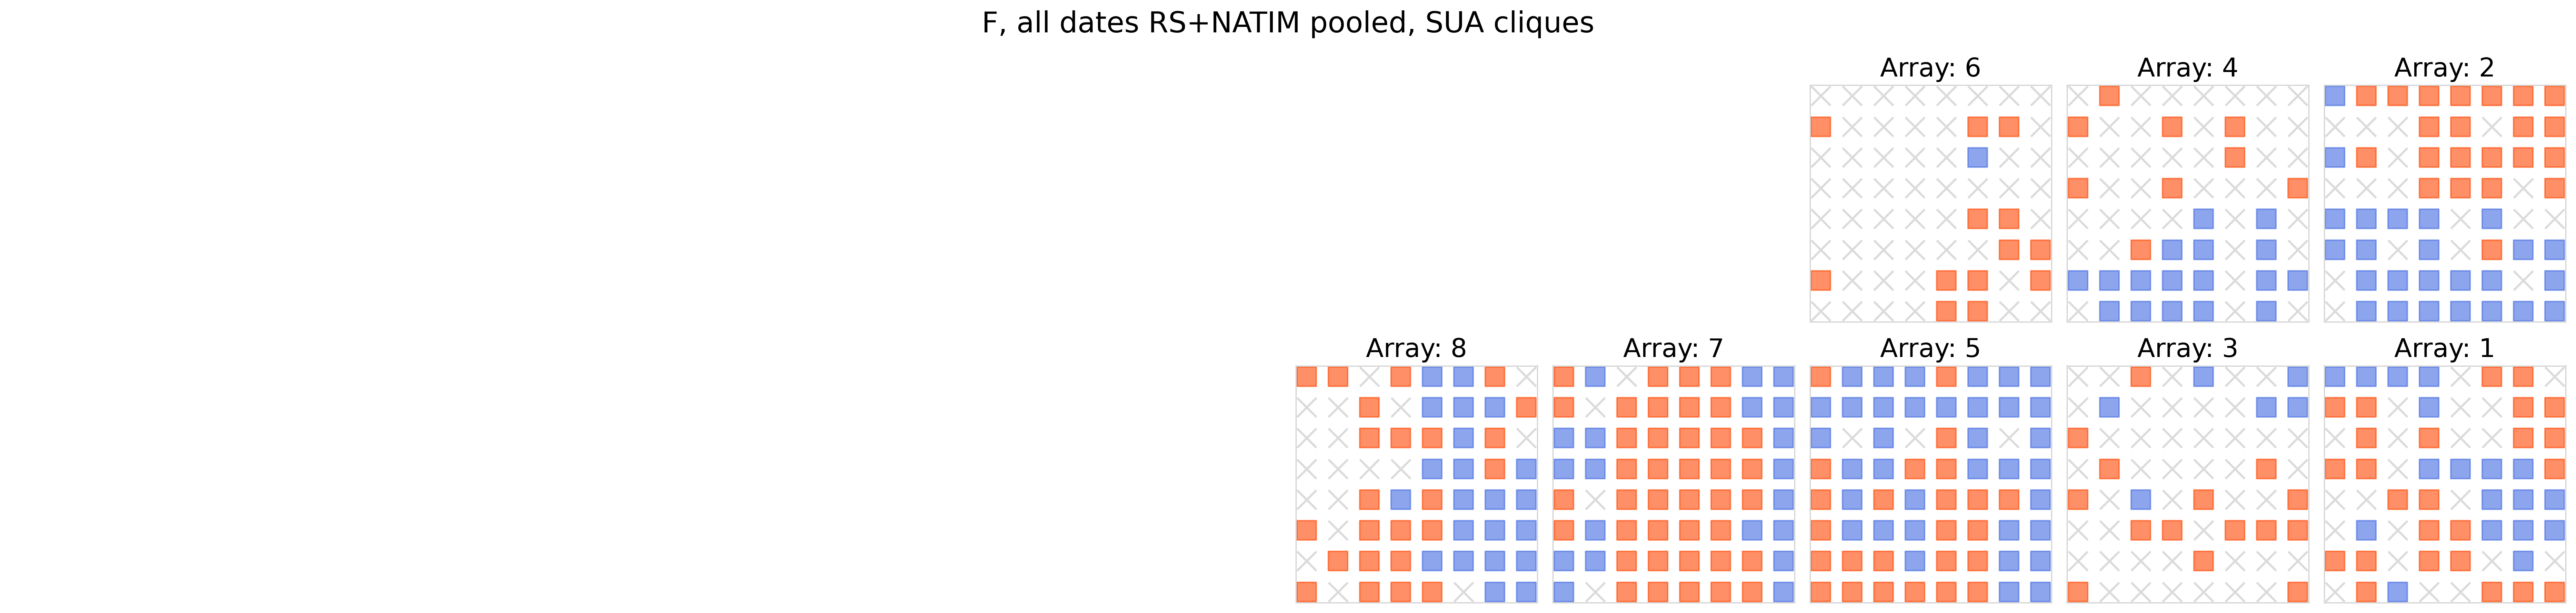

F: {'orange': 173, 'blue': 145, 'gray': 194, 'white': 0} (512 channels classified)



In [11]:
color_dict = {'blue':'royalblue',
              'orange':'orangered',
              'gray':'lightgray',
              'white':'white'}

clique_counts = {}   # clique_counts[monkey] -> {'orange':n, 'blue':n, 'gray':n, 'white':n}, filled in during the plotting loop below

for monkey in MONKEY_LIST:
    layout_odd = np.array(params['layout'][f'{monkey}_odd'])
    layout_even = np.array(params['layout'][f'{monkey}_even'])

    monkey_dfs_list = []
    for condition, folder in CONDITION_FOLDERS.items():
        dates_this_condition = params['dates'][monkey].get(condition, [])
        for date in dates_this_condition:
            print(f'{monkey} {condition} {date}')
            with open(f'{DF_FOLDER}/{folder}/monkey{monkey}_all_arrays_date_{date}.pkl', "rb") as file:
                df_prop = pickle.load(file)
                df_prop = df_prop[~df_prop['ch_is_noisy_120Hz']]
                df_prop = df_prop[~df_prop['ch_is_noisy_100Hz']]
            monkey_dfs_list.append(df_prop)
    df_all = pd.concat(monkey_dfs_list)

    n_rows = n_rows_dict[monkey]
    n_cols = n_cols_dict[monkey]
    fig, ax = plt.subplots(n_rows,n_cols,dpi=300)
    fig.set_figwidth(2.5*n_cols)
    fig.set_figheight(2.5*n_rows+1)

    plt.suptitle(f'{monkey}, all dates RS+NATIM pooled, SUA cliques',fontsize=20)

    for r in range(n_rows):
        for c in range(n_cols):
            ax[r,c].set_xticks([])
            ax[r,c].set_yticks([])
            for spine in ax[r,c].spines.values():
                spine.set_color('white')

    monkey_labels = []
    for array in range(1,17):
        if array%2==0:
            layout = layout_even
        else:
            layout = layout_odd

        ch_layout_indices = []
        for ch in range(64):
            layout_idx = np.where(layout==ch)
            layout_idx = np.array([layout_idx[0][0], layout_idx[1][0]]) # reformating from array of arrays to array of two integer coors.
            ch_layout_indices.append(layout_idx)

        if params['areas'][monkey][array-1] in ['V1','V2']:
            ch_dict = aux_units_on_ch(df_all,array,final_classes=FINAL_CLASSES)
            clique_dict = aux_dominant_clique_on_ch(ch_dict)
            monkey_labels.extend(clique_dict.values())

            area = params['areas'][monkey][array-1]
            row_plot = arrays_coors[monkey][array-1][0]
            col_plot = arrays_coors[monkey][array-1][1]
            ax[row_plot,col_plot].set_title(f'Array: {array}',fontsize=18)
            for ch in range(64):
                coor = ch_layout_indices[ch]
                color = clique_dict[ch]

                row = coor[1]
                col = coor[0]
                if color in ['orange','blue']:
                    ax[row_plot,col_plot].scatter(row,8-col,c=color_dict[color],alpha=0.6,s=180,marker='s')
                else:
                    ax[row_plot,col_plot].scatter(row,8-col,c=color_dict[color],alpha=0.8,s=180,marker='x')
                for spine in ax[row_plot,col_plot].spines.values():
                    spine.set_color('lightgray')

    clique_counts[monkey] = {c: monkey_labels.count(c) for c in ['orange','blue','gray','white']}
    plt.tight_layout()
    plt.show()
    plt.close()
    print(f'{monkey}: {clique_counts[monkey]} ({len(monkey_labels)} channels classified)\n')

## Statistics

Two questions, tested on the same pooled channel counts used for the maps above:

1. **Within each monkey**, is the orange/blue split different from 50/50? Two-sided exact binomial test on `orange` vs `orange+blue` (channels classified `gray`/`white` are excluded - they are ties or below-threshold, not evidence either way).
2. **Across monkeys**, is the orange:blue ratio the same in all three? Chi-square test of independence on the monkey x {orange,blue} contingency table, followed by pairwise chi-square tests between monkeys with Bonferroni correction (same correction convention as `SF9_testing_NATIM_RS`).

In [12]:
df_counts = pd.DataFrame(clique_counts).T  # rows = monkey, cols = orange/blue/gray/white
df_counts.index.name = 'monkey'
df_counts['total'] = df_counts[['orange','blue','gray','white']].sum(axis=1)
for c in ['orange','blue','gray','white']:
    df_counts[f'{c}_pct'] = 100*df_counts[c]/df_counts['total']
df_counts

,orange,blue,gray,white,total,orange_pct,blue_pct,gray_pct,white_pct
monkey,,,,,,,,,
L,209,119,568,0,896,23.325893,13.281250,63.392857,0.0
N,216,122,110,0,448,48.214286,27.232143,24.553571,0.0
F,173,145,194,0,512,33.789062,28.320312,37.890625,0.0


In [13]:
print('Per-monkey binomial test: orange vs blue (H0: 50/50)\n')
binom_rows = []
for monkey in MONKEY_LIST:
    n_orange = clique_counts[monkey]['orange']
    n_blue = clique_counts[monkey]['blue']
    n_ob = n_orange + n_blue
    result = binomtest(n_orange, n_ob, p=0.5, alternative='two-sided')
    binom_rows.append({'monkey':monkey, 'n_orange':n_orange, 'n_blue':n_blue,
                        'pct_orange':100*n_orange/n_ob, 'p_value':result.pvalue})
    print(f'{monkey}: orange={n_orange}, blue={n_blue} ({100*n_orange/n_ob:.1f}% orange), p={result.pvalue:.4g}')

df_binom = pd.DataFrame(binom_rows)
df_binom['p_bonf'] = np.minimum(df_binom['p_value']*len(df_binom), 1.0)
df_binom

Per-monkey binomial test: orange vs blue (H0: 50/50)

L: orange=209, blue=119 (63.7% orange), p=7.657e-07
N: orange=216, blue=122 (63.9% orange), p=3.579e-07
F: orange=173, blue=145 (54.4% orange), p=0.1299


,monkey,n_orange,n_blue,pct_orange,p_value,p_bonf
0,L,209,119,63.719512,7.657323e-07,0.000002
1,N,216,122,63.905325,3.579274e-07,0.000001
2,F,173,145,54.402516,1.298744e-01,0.389623


In [14]:
contingency = df_counts.loc[MONKEY_LIST, ['orange','blue']].values
chi2, p_omnibus, dof, expected = chi2_contingency(contingency)
print(f'Omnibus chi-square test (monkey x orange/blue), all 3 monkeys together: '
      f'chi2={chi2:.3f}, dof={dof}, p={p_omnibus:.4g}\n')

print('Pairwise chi-square tests between monkeys (Bonferroni-corrected):\n')
pair_rows = []
for i in range(len(MONKEY_LIST)):
    for j in range(i+1, len(MONKEY_LIST)):
        m1, m2 = MONKEY_LIST[i], MONKEY_LIST[j]
        table = df_counts.loc[[m1,m2], ['orange','blue']].values
        chi2_pair, p_pair, _, _ = chi2_contingency(table)
        pair_rows.append({'monkey_1':m1, 'monkey_2':m2, 'chi2':chi2_pair, 'p_value':p_pair})

df_pairs = pd.DataFrame(pair_rows)
_, p_bonf, _, _ = multipletests(df_pairs['p_value'], method='bonferroni')
df_pairs['p_bonf'] = p_bonf
df_pairs

Omnibus chi-square test (monkey x orange/blue), all 3 monkeys together: chi2=7.999, dof=2, p=0.01832

Pairwise chi-square tests between monkeys (Bonferroni-corrected):



,monkey_1,monkey_2,chi2,p_value,p_bonf
0,L,N,0.000000,1.000000,1.000000
1,L,F,5.420731,0.019899,0.059697
2,N,F,5.743021,0.016554,0.049663
